# 🛠️ Notebook 02 — Data Cleaning & Feature Engineering
## SentimentCompass: Understanding User Satisfaction, Topic Trends, and Migration Signals

---

**Project:** SentimentCompass  
**Input:** `data/raw/The__Generative_AI_Ecosystem_50k_User_Reviews_2026.csv`  
**Output:** `data/processed/reviews_clean.parquet` + `reviews_clean.csv`  
**Purpose:** Produce the master cleaned dataset used by every downstream notebook.

### 🎯 Objectives

| # | Objective |
|---|-----------|
| 1 | Clean and standardise review text (unicode, URLs, HTML, whitespace) |
| 2 | Handle missing values and flag duplicate text |
| 3 | Create `review_text_clean` — display-ready cleaned text |
| 4 | Create `review_text_nlp` — NLP-ready tokenised + lemmatised text |
| 5 | Engineer 22 analytical features across text, date, rating, and engagement dimensions |
| 6 | Validate all outputs and save the processed dataset |

### 📋 Table of Contents

| # | Section | New columns |
|---|---------|------------|
| 1 | Setup & Configuration | — |
| 2 | Load Dataset | — |
| 3 | Data Cleaning | `review_text_clean`, `is_duplicate_text` |
| 4 | NLP Text Preprocessing | `review_text_nlp` |
| 5 | Feature Engineering | 19 features |
| 6 | Quality Validation | — |
| 7 | Save Outputs | `reviews_clean.parquet`, `reviews_clean.csv` |
| 8 | Preprocessing Summary | — |

> 📁 All 5 figures saved to `../outputs/figures/` at 300 DPI.

---
## ⚙️ Section 1 — Setup & Configuration

All imports, palette definitions, and helper functions are centralised here for reproducibility. The `clean_text()` and `create_nlp_text()` functions defined later are designed to be **importable as standalone utilities** in other notebooks.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import time
import warnings
import unicodedata

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Display ───────────────────────────────────────────────────────────────────
from IPython.display import display, HTML

# ── Download NLTK resources (quiet — no output if already present) ────────────
for _res in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(_res, quiet=True)
    except Exception:
        pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 90)

# ── Global matplotlib style (consistent with Notebook 01) ─────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "grid.color"        : "#E8E8E8",
    "grid.linewidth"    : 0.8,
    "legend.fontsize"   : 9,
    "legend.framealpha" : 0.92,
})

# ── Platform colour palette ───────────────────────────────────────────────────
APP_COLORS = {
    "ChatGPT"           : "#1D9E75",
    "Google_Gemini"     : "#378ADD",
    "Claude"            : "#534AB7",
    "Microsoft_Copilot" : "#BA7517",
    "Perplexity"        : "#D85A30",
}
APP_ORDER  = ["ChatGPT", "Google_Gemini", "Claude", "Microsoft_Copilot", "Perplexity"]
APP_LABELS = {
    "ChatGPT"           : "ChatGPT",
    "Google_Gemini"     : "Gemini",
    "Claude"            : "Claude",
    "Microsoft_Copilot" : "MS Copilot",
    "Perplexity"        : "Perplexity",
}
PALETTE      = [APP_COLORS[a] for a in APP_ORDER]
STAR_COLORS  = ["#E24B4A", "#F5923E", "#F5C518", "#8DC265", "#1D9E75"]
CAT_COLORS   = {"Positive": "#1D9E75", "Neutral": "#F5C518", "Negative": "#E24B4A"}

# ── I/O paths ─────────────────────────────────────────────────────────────────
RAW_PATH      = "../data/raw/The__Generative_AI_Ecosystem_50k_User_Reviews_2026.csv"
PROCESSED_DIR = "../data/processed/"
FIGURES_DIR   = "../outputs/figures/"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,   exist_ok=True)

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  📁  Saved → {path}")

print("✅  Setup complete.")
print(f"    Processed dir : {os.path.abspath(PROCESSED_DIR)}")
print(f"    Figures dir   : {os.path.abspath(FIGURES_DIR)}")

✅  Setup complete.
    Processed dir : C:\Users\admin\Desktop\VS CODE\AI-Platform-Sentiment-and-Migration-Analysis\data\processed
    Figures dir   : C:\Users\admin\Desktop\VS CODE\AI-Platform-Sentiment-and-Migration-Analysis\outputs\figures


---
## 📂 Section 2 — Load Dataset

We load the raw CSV and immediately parse `Review_Date`. We also record the original row count so the preprocessing summary can report exactly how many rows were affected by each step.

In [2]:
df = pd.read_csv(RAW_PATH)
df["Review_Date"] = pd.to_datetime(df["Review_Date"])

ORIGINAL_ROWS = len(df)

print("=" * 58)
print("  DATASET LOADED")
print("=" * 58)
print(f"  Rows       : {df.shape[0]:>10,}")
print(f"  Columns    : {df.shape[1]:>10}")
print(f"  Memory     : {df.memory_usage(deep=True).sum() / 1e6:>9.2f} MB")
print(f"  Date range : {df['Review_Date'].min().date()}  →  {df['Review_Date'].max().date()}")
print("=" * 58)
print()
print("Existing columns:")
for col in df.columns:
    nulls = df[col].isnull().sum()
    print(f"  {col:<28} dtype={str(df[col].dtype):<12}  nulls={nulls:,}")

  DATASET LOADED
  Rows       :     50,000
  Columns    :         10
  Memory     :     13.15 MB
  Date range : 2025-05-13  →  2026-03-31

Existing columns:
  App                          dtype=str           nulls=0
  Review_Date                  dtype=datetime64[us]  nulls=0
  Star_Rating                  dtype=int64         nulls=0
  Review_Text                  dtype=str           nulls=0
  Word_Count                   dtype=int64         nulls=0
  Review_Length_Chars          dtype=int64         nulls=0
  Thumbs_Up_Count              dtype=int64         nulls=0
  App_Version                  dtype=str           nulls=6,912
  Sentiment_Polarity           dtype=float64       nulls=0
  Review_Theme                 dtype=str           nulls=0


---
## 🧹 Section 3 — Data Cleaning

Three cleaning steps are applied in sequence:
1. **Text cleaning** — creates `review_text_clean` from `Review_Text`
2. **Missing value treatment** — imputes `App_Version`
3. **Duplicate handling** — flags duplicate `Review_Text` values

> **Design principle:** We do NOT remove punctuation that carries sentiment signal (`!`, `?`, `...`). We preserve case in `review_text_clean` — lowercasing happens only in the NLP preprocessing step.

### 3.1 Text cleaning pipeline

The `clean_text()` function applies 8 steps in order. Each step is applied only when the previous step's output is non-empty.

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Unicode NFKC normalisation | Converts fancy Unicode letters/symbols to standard forms |
| 2 | Remove URLs | URLs add noise but no sentiment |
| 3 | Remove HTML tags | Strip any `<b>`, `<br>` artifacts from web scraping |
| 4 | Remove email addresses | Personally identifiable; irrelevant to sentiment |
| 5 | Normalise smart quotes & dashes | Standardises `'`, `"`, `—` to ASCII equivalents |
| 6 | Remove non-content special characters | Keeps `.,!?'"-` which carry sentiment or grammatical meaning |
| 7 | Collapse repeated punctuation | `!!!` → `!`; `???` → `?`; `....` → `...` |
| 8 | Normalise whitespace | Removes double spaces, leading/trailing spaces |

In [3]:
def clean_text(text):
    # Handle null / empty inputs
    if pd.isna(text) or not str(text).strip():
        return ""
    text = str(text)

    # Step 1 — Unicode NFKC normalisation
    text = unicodedata.normalize("NFKC", text)

    # Step 2 — Remove URLs
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+",     " ", text)

    # Step 3 — Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Step 4 — Remove email addresses
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Step 5 — Normalise smart quotes and dashes
    replacements = {
        "\u2019": "'",  "\u2018": "'",   # smart single quotes
        "\u201c": '"',  "\u201d": '"',   # smart double quotes
        "\u2013": "-",  "\u2014": "-",   # en/em dashes
        "\u2026": "...",                  # ellipsis character
        "\u00a0": " ",                    # non-breaking space
    }
    for src, tgt in replacements.items():
        text = text.replace(src, tgt)

    # Step 6 — Remove non-content special characters
    # Keep: word chars, spaces, . , ! ? ' " - (sentiment-bearing punctuation)
    text = re.sub(r"[^\w\s.,!?'\"\-]", " ", text)

    # Step 7 — Collapse repeated punctuation
    text = re.sub(r"!{2,}",  "!",   text)
    text = re.sub(r"\?{2,}", "?",   text)
    text = re.sub(r"\.{4,}", "...", text)

    # Step 8 — Normalise whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ── Verify on a few manual examples ───────────────────────────────────────────
test_cases = [
    "Visit https://openai.com for more!!!",
    "Email me at user@example.com \u2014 it\u2019s amazing!!!",
    "<b>Best app</b> ever???",
    "I\u2019m NOT happy   with this   update.",
    "\U0001f4a5 Best AI ever! Works great",
]
print("clean_text() test cases:")
print("-" * 65)
for t in test_cases:
    print(f"  IN : {t[:60]}")
    print(f"  OUT: {clean_text(t)}")
    print()

clean_text() test cases:
-----------------------------------------------------------------
  IN : Visit https://openai.com for more!!!
  OUT: Visit for more!

  IN : Email me at user@example.com — it’s amazing!!!
  OUT: Email me at - it's amazing!

  IN : <b>Best app</b> ever???
  OUT: Best app ever?

  IN : I’m NOT happy   with this   update.
  OUT: I'm NOT happy with this update.

  IN : 💥 Best AI ever! Works great
  OUT: Best AI ever! Works great



In [4]:
print("Applying clean_text() to all 50,000 reviews...")
_t0 = time.time()

df["review_text_clean"] = df["Review_Text"].apply(clean_text)

_elapsed = time.time() - _t0
print(f"✅  Done in {_elapsed:.1f}s")
print()

# ── Quality report ────────────────────────────────────────────────────────────
empty_clean = (df["review_text_clean"].str.strip() == "").sum()
mean_before = df["Review_Length_Chars"].mean()
mean_after  = df["review_text_clean"].str.len().mean()

print("Cleaning impact:")
print(f"  Non-empty reviews         : {len(df) - empty_clean:,} / {len(df):,}")
print(f"  Empty after cleaning      : {empty_clean}")
print(f"  Avg length BEFORE (chars) : {mean_before:.1f}")
print(f"  Avg length AFTER  (chars) : {mean_after:.1f}")
print(f"  Avg reduction             : {mean_before - mean_after:.1f} chars "
      f"({(mean_before - mean_after) / mean_before * 100:.1f}%)")

Applying clean_text() to all 50,000 reviews...
✅  Done in 1.8s

Cleaning impact:
  Non-empty reviews         : 50,000 / 50,000
  Empty after cleaning      : 0
  Avg length BEFORE (chars) : 149.3
  Avg length AFTER  (chars) : 148.2
  Avg reduction             : 1.2 chars (0.8%)


### 3.2 Missing value treatment

From the EDA (Notebook 01), only `App_Version` has missing values (13.8%). All other columns are complete. We impute `App_Version` with `'Unknown'` — a meaningful sentinel that allows us to group these reviews in version-level analysis without dropping them.

In [5]:
# ── Track what we impute ──────────────────────────────────────────────────────
mv_before = df.isnull().sum()
n_av_missing = df["App_Version"].isnull().sum()

# Impute App_Version
df["App_Version"] = df["App_Version"].fillna("Unknown")

mv_after  = df.isnull().sum()

print("Missing value treatment report:")
print("-" * 52)
print(f"  App_Version  : {n_av_missing:,} nulls → filled with 'Unknown'")
print()
print("Remaining nulls after imputation:")
for col in df.columns:
    n = df[col].isnull().sum()
    if n > 0:
        print(f"  {col:<28} : {n:,}")
if mv_after.sum() == 0:
    print("  ✅  Zero nulls remaining in all columns.")

Missing value treatment report:
----------------------------------------------------
  App_Version  : 6,912 nulls → filled with 'Unknown'

Remaining nulls after imputation:
  ✅  Zero nulls remaining in all columns.


### 3.3 Duplicate handling

**Exact row duplicates** are removed (in-place). **Duplicate `Review_Text`** values (same review text appearing in multiple rows, possibly across platforms) are flagged with a new binary column `is_duplicate_text` rather than dropped — they represent an analytically interesting pattern discovered in the EDA (possible cross-platform bot activity).

In [6]:
# ── Exact row duplicates ──────────────────────────────────────────────────────
n_exact_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_exact_removed = n_exact_before - len(df)

print(f"Exact row duplicates removed : {n_exact_removed}")
print(f"Rows after deduplication     : {len(df):,}")

# ── Flag duplicate Review_Text ────────────────────────────────────────────────
df["is_duplicate_text"] = df["Review_Text"].duplicated(keep=False).astype(int)
n_dup_text = df["is_duplicate_text"].sum()

print(f"\nDuplicate Review_Text rows flagged : {n_dup_text}  "
      f"({n_dup_text / len(df) * 100:.3f}%)")

if n_dup_text > 0:
    print("\nCross-platform duplicate examples (first 3):")
    dup_sample = (df[df["is_duplicate_text"] == 1]
                  .sort_values("Review_Text")
                  .groupby("Review_Text")
                  .first()
                  .reset_index()
                  .head(3))
    for _, row in dup_sample.iterrows():
        apps = df[df["Review_Text"] == row["Review_Text"]]["App"].tolist()
        print(f"  Apps involved : {apps}")
        print(f"  Text (60 chars): \"{str(row['Review_Text'])[:60]}\"")
        print()

Exact row duplicates removed : 0
Rows after deduplication     : 50,000

Duplicate Review_Text rows flagged : 17  (0.034%)

Cross-platform duplicate examples (first 3):
  Apps involved : ['Microsoft_Copilot', 'Claude']
  Text (60 chars): ""The AI system is strong, but the code structure and feature"

  Apps involved : ['Google_Gemini', 'Google_Gemini']
  Text (60 chars): "Based on this analysis: 1. Suggest at least 10 modern hairst"

  Apps involved : ['Microsoft_Copilot', 'Google_Gemini']
  Text (60 chars): "DO NOT USE THIS. Under any normal circumstances, this app sh"



  📁  Saved → ../outputs/figures/fig_nb02_01_cleaning_impact.png


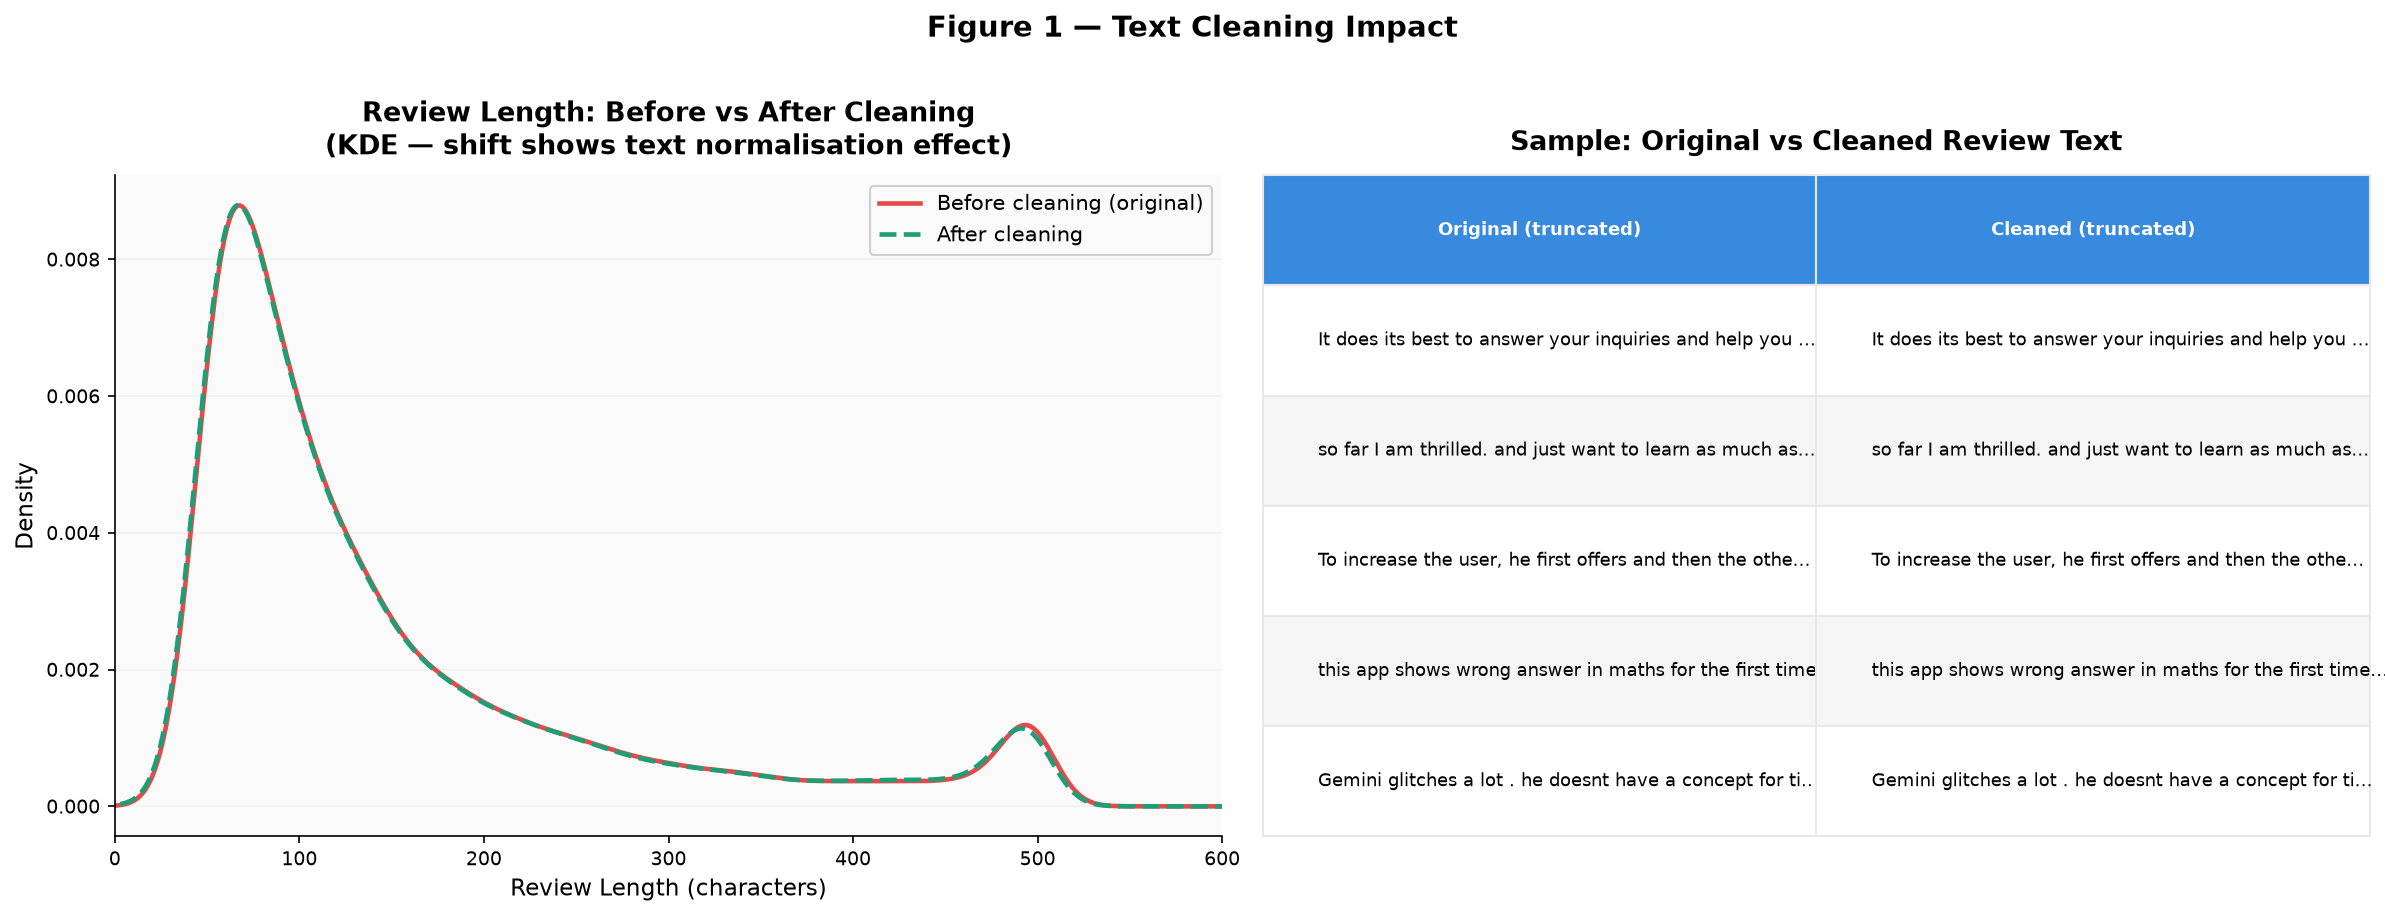

In [7]:
# ── Figure 1: Cleaning impact ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: KDE before vs after
df["Review_Length_Chars"].plot(
    kind="kde", ax=axes[0], color="#E24B4A",
    linewidth=2.2, label="Before cleaning (original)"
)
df["review_text_clean"].str.len().plot(
    kind="kde", ax=axes[0], color="#1D9E75",
    linewidth=2.2, linestyle="--", label="After cleaning"
)
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 600)
axes[0].set_title("Review Length: Before vs After Cleaning\n(KDE — shift shows text normalisation effect)",
                  fontweight="bold", pad=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.5)

# Right: Sample showcase table (text)
samples = df[df["review_text_clean"].str.len() > 20].sample(5, random_state=42)
axes[1].axis("off")
table_data  = []
col_labels  = ["Original (truncated)", "Cleaned (truncated)"]
for _, row in samples.iterrows():
    orig    = str(row["Review_Text"])[:55] + "..."
    cleaned = str(row["review_text_clean"])[:55] + "..."
    table_data.append([orig, cleaned])

tbl = axes[1].table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#378ADD")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F5F5F5")
    cell.set_edgecolor("#E8E8E8")
axes[1].set_title("Sample: Original vs Cleaned Review Text",
                  fontweight="bold", pad=12)

plt.suptitle("Figure 1 — Text Cleaning Impact",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb02_01_cleaning_impact.png")
plt.show()

---
## 🔤 Section 4 — NLP Text Preprocessing

`review_text_nlp` is the column used by **Notebook 04 (Topic Modeling)** and **Notebook 05 (Migration Analysis)**. It contains the core semantic content of each review — stopwords and noise removed, words reduced to their base forms.

**Pipeline steps:**
1. Lowercase
2. Tokenise with NLTK `word_tokenize`
3. Keep only alphabetic tokens longer than 2 characters
4. Remove stopwords — **preserving negations** (`not`, `no`, `never`, etc.)
5. Lemmatise with `WordNetLemmatizer`
6. Rejoin as a single space-separated string

In [8]:
# ── Initialise NLP resources ───────────────────────────────────────────────────
LEMMATIZER = WordNetLemmatizer()

# Keep negations so sentiment context is preserved in topic modelling
_NEGATIONS  = {"not", "no", "never", "nor", "neither", "nothing",
               "nowhere", "nobody", "none", "cannot", "cant", "wont",
               "didnt", "doesnt", "dont", "isnt", "wasnt", "shouldnt",
               "wouldnt", "couldnt", "hasnt", "hadnt", "havent"}
STOP_WORDS  = set(stopwords.words("english")) - _NEGATIONS

# AI-domain custom stopwords (common but content-free in this corpus)
_DOMAIN_STOP = {"app", "use", "using", "used", "like", "get", "got",
                "also", "even", "one", "would", "could", "really",
                "just", "still", "way", "make", "made", "well", "go"}
STOP_WORDS   = STOP_WORDS | _DOMAIN_STOP

print(f"Total stopwords applied : {len(STOP_WORDS)}")
print(f"Negations preserved     : {len(_NEGATIONS)}")
print(f"Domain stopwords added  : {len(_DOMAIN_STOP)}")
print()
print(f"NLTK version : {nltk.__version__}")

Total stopwords applied : 214
Negations preserved     : 23
Domain stopwords added  : 20

NLTK version : 3.9.4


### 4.2 `create_nlp_text()` function

This function converts a cleaned review string into a space-joined string of lemmatised content words. The output is directly consumed by `gensim.corpora.Dictionary` in the LDA pipeline and `BERTopic` in Notebook 04.

In [9]:
def create_nlp_text(text):
    # Guard: handle null / empty
    if not isinstance(text, str) or not text.strip():
        return ""

    # Step 1 — Lowercase
    text = text.lower()

    # Step 2 — Tokenise
    try:
        tokens = word_tokenize(text)
    except Exception:
        tokens = text.split()

    # Step 3 — Keep alphabetic tokens longer than 2 characters
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2]

    # Step 4 — Remove stopwords (negations are kept)
    tokens = [t for t in tokens if t not in STOP_WORDS]

    # Step 5 — Lemmatise (using default noun POS for efficiency)
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    # Step 6 — Post-lemmatisation filter (remove any new short tokens)
    tokens = [t for t in tokens if len(t) > 2]

    return " ".join(tokens)


# ── Unit test the function ────────────────────────────────────────────────────
_tests = [
    "This app is not working properly and the updates are terrible",
    "Absolutely amazing AI tool! Best assistant I have ever used.",
    "The pricing is way too expensive for what you get",
    "Switched from ChatGPT to Claude because it handles longer texts better",
]
print("create_nlp_text() examples:")
print("-" * 65)
for t in _tests:
    print(f"  IN : {t}")
    print(f"  OUT: {create_nlp_text(t)}")
    print()

create_nlp_text() examples:
-----------------------------------------------------------------
  IN : This app is not working properly and the updates are terrible
  OUT: not working properly update terrible

  IN : Absolutely amazing AI tool! Best assistant I have ever used.
  OUT: absolutely amazing tool best assistant ever

  IN : The pricing is way too expensive for what you get
  OUT: pricing expensive

  IN : Switched from ChatGPT to Claude because it handles longer texts better
  OUT: switched chatgpt claude handle longer text better



In [10]:
print("Creating review_text_nlp — processing 50,000 reviews in chunks...")
print("(Expected: ~1–3 minutes depending on hardware)\n")

_t0         = time.time()
_chunk_size = 10_000
_results    = []

for _i in range(0, len(df), _chunk_size):
    _chunk = df.iloc[_i : _i + _chunk_size]["review_text_clean"]
    _results.extend(_chunk.apply(create_nlp_text).tolist())
    _done    = min(_i + _chunk_size, len(df))
    _elapsed = time.time() - _t0
    _pct     = _done / len(df) * 100
    print(f"  [{_pct:>5.1f}%]  {_done:>6,} / {len(df):,} reviews  "
          f"({_elapsed:.0f}s elapsed)")

df["review_text_nlp"] = _results
_total = time.time() - _t0
print(f"\n✅  Completed in {_total:.1f}s  "
      f"({_total / len(df) * 1000:.2f} ms/review)")

Creating review_text_nlp — processing 50,000 reviews in chunks...
(Expected: ~1–3 minutes depending on hardware)

  [ 20.0%]  10,000 / 50,000 reviews  (2s elapsed)
  [ 40.0%]  20,000 / 50,000 reviews  (4s elapsed)
  [ 60.0%]  30,000 / 50,000 reviews  (7s elapsed)
  [ 80.0%]  40,000 / 50,000 reviews  (9s elapsed)
  [100.0%]  50,000 / 50,000 reviews  (12s elapsed)

✅  Completed in 12.3s  (0.25 ms/review)


In [11]:
# ── Side-by-side preview ──────────────────────────────────────────────────────
print("Text preprocessing preview — one example per platform:")
print("=" * 90)
for app in APP_ORDER:
    row = df[df["App"] == app].iloc[0]
    print(f"\n  Platform     : {APP_LABELS[app]}")
    print(f"  Original     : {str(row['Review_Text'])[:110]}")
    print(f"  Cleaned      : {str(row['review_text_clean'])[:110]}")
    print(f"  NLP tokens   : {str(row['review_text_nlp'])[:110]}")
    print()

# ── NLP quality stats ─────────────────────────────────────────────────────────
nlp_nonempty = (df["review_text_nlp"].str.strip() != "").mean() * 100
nlp_lengths  = df["review_text_nlp"].str.split().str.len().describe()
print("=" * 90)
print(f"\nNLP text quality:")
print(f"  Non-empty rows          : {nlp_nonempty:.2f}%")
print(f"  Mean token count        : {nlp_lengths['mean']:.1f}")
print(f"  Median token count      : {nlp_lengths['50%']:.0f}")
print(f"  Min / Max token count   : {int(nlp_lengths['min'])} / {int(nlp_lengths['max'])}")

Text preprocessing preview — one example per platform:

  Platform     : ChatGPT
  Original     : 𝐈 𝐚𝐦 𝐥𝐨𝐯𝐢𝐧𝐠 𝐢𝐭. 𝐈 𝐤𝐧𝐨𝐰𝐚 𝐥𝐨𝐭 𝐨𝐟 𝐭𝐡𝐢𝐧𝐠𝐬 𝐧𝐨𝐰 𝐞𝐚𝐬𝐲 𝐰𝐚𝐲. 𝐈 𝐝𝐨𝐧𝐭 𝐮𝐬𝐞 𝐠𝐨𝐨𝐠𝐥𝐞 𝐚𝐧𝐲 𝐦𝐨𝐫𝐞.
  Cleaned      : I am loving it. I knowa lot of things now easy way. I dont use google any more.
  NLP tokens   : loving knowa lot thing easy dont google


  Platform     : Gemini
  Original     : Started off well om my laptop..It is far better on my phone. Now it is not doing a very good job on the laptop
  Cleaned      : Started off well om my laptop..It is far better on my phone. Now it is not doing a very good job on the laptop
  NLP tokens   : started laptop far better phone not good job unable create simple image coming excuse make excuse fails precis


  Platform     : Claude
  Original     : Claude by Anthropic is an amazing AI assistant that is willing to help you by generating extremely high qualit
  Cleaned      : Claude by Anthropic is an amazing AI assistant that is willing to help you by generatin

---
## ⚙️ Section 5 — Feature Engineering

We engineer 19 analytical features grouped into four categories:

| Category | Features | Used in |
|----------|----------|---------|
| Text | `review_length_chars`, `review_length_words`, `sentence_count`, `avg_word_length`, `exclamation_count`, `question_count`, `uppercase_ratio`, `thumbs_log` | NB03, NB06 |
| Date | `review_year`, `review_month`, `review_day`, `review_weekday`, `review_weekday_name` | Dashboard |
| Rating | `is_positive_review`, `is_negative_review`, `is_neutral_review` | NB03, NB05 |
| Influence | `is_influential_review` | NB03 (TWSI) |

### 5.1 Text-derived features

**Design decisions:**
- `uppercase_ratio` is computed from the **original** `Review_Text` (before normalisation) to capture the user's original writing style
- `exclamation_count` and `question_count` are computed from `review_text_clean` (after deduplication of `!!!` → `!`)
- `thumbs_log` uses `log(1 + x)` to handle the extreme right-skew confirmed in EDA

In [12]:
_t0 = time.time()

# ── 1. review_length_chars ────────────────────────────────────────────────────
df["review_length_chars"] = df["review_text_clean"].str.len().fillna(0).astype(int)

# ── 2. review_length_words ────────────────────────────────────────────────────
df["review_length_words"] = (
    df["review_text_clean"]
    .apply(lambda x: len(str(x).split()) if isinstance(x, str) and x.strip() else 0)
)

# ── 3. sentence_count (regex-based — faster than sent_tokenize for 50K rows) ──
def _count_sentences(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    parts = re.split(r"[.!?]+\s+|[.!?]+$", text.strip())
    return max(1, len([p for p in parts if p.strip()]))

df["sentence_count"] = df["review_text_clean"].apply(_count_sentences)

# ── 4. avg_word_length ────────────────────────────────────────────────────────
def _avg_word_len(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    words = [w for w in text.split() if w.isalpha()]
    return round(np.mean([len(w) for w in words]), 4) if words else 0.0

df["avg_word_length"] = df["review_text_clean"].apply(_avg_word_len)

# ── 5. exclamation_count ──────────────────────────────────────────────────────
df["exclamation_count"] = (
    df["review_text_clean"].str.count("!").fillna(0).astype(int)
)

# ── 6. question_count ─────────────────────────────────────────────────────────
df["question_count"] = (
    df["review_text_clean"].str.count(r"\?").fillna(0).astype(int)
)

# ── 7. uppercase_ratio (from ORIGINAL text — captures writing style) ──────────
def _uppercase_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    alpha = [c for c in text if c.isalpha()]
    if not alpha:
        return 0.0
    return round(sum(1 for c in alpha if c.isupper()) / len(alpha), 4)

df["uppercase_ratio"] = df["Review_Text"].apply(_uppercase_ratio)

# ── 8. thumbs_log ─────────────────────────────────────────────────────────────
df["thumbs_log"] = np.log1p(df["Thumbs_Up_Count"]).round(4)

print(f"✅  Text features created in {time.time()-_t0:.1f}s")
print()
_text_feats = ["review_length_chars", "review_length_words", "sentence_count",
               "avg_word_length", "exclamation_count", "question_count",
               "uppercase_ratio", "thumbs_log"]
print("Text feature statistics:")
print(df[_text_feats].describe().round(3).to_string())

✅  Text features created in 3.3s

Text feature statistics:
       review_length_chars  review_length_words  sentence_count  avg_word_length  exclamation_count  question_count  uppercase_ratio  thumbs_log
count           50000.0000           50000.0000      50000.0000       50000.0000         50000.0000      50000.0000       50000.0000  50000.0000
mean              148.1600              27.6570          1.9980           4.2030             0.1270          0.0360           0.0360      0.2880
std               116.7450              21.7190          1.5470           0.7180             0.4740          0.2330           0.0830      0.6660
min                 4.0000               1.0000          1.0000           0.0000             0.0000          0.0000           0.0000      0.0000
25%                68.0000              13.0000          1.0000           3.7780             0.0000          0.0000           0.0070      0.0000
50%               103.0000              19.0000          1.0000        

### 5.2 Date features

Extracted from `Review_Date`. These are used in the dashboard for temporal filtering and in the migration analysis to identify when competitive switching peaks.

In [13]:
df["review_year"]         = df["Review_Date"].dt.year
df["review_month"]        = df["Review_Date"].dt.month
df["review_day"]          = df["Review_Date"].dt.day
df["review_weekday"]      = df["Review_Date"].dt.dayofweek   # 0=Monday, 6=Sunday
df["review_weekday_name"] = df["Review_Date"].dt.day_name()

print("Date features created:")
print(f"  review_year         : {df['review_year'].min()} – {df['review_year'].max()}")
print(f"  review_month        : {df['review_month'].min()} – {df['review_month'].max()}")
print(f"  review_weekday      : 0 (Mon) – 6 (Sun)")
print(f"  review_weekday_name : {df['review_weekday_name'].unique().tolist()}")
print()
print("Reviews by month:")
print(df["review_month"].value_counts().sort_index().to_string())

Date features created:
  review_year         : 2025 – 2026
  review_month        : 1 – 12
  review_weekday      : 0 (Mon) – 6 (Sun)
  review_weekday_name : ['Tuesday', 'Monday', 'Sunday', 'Saturday', 'Friday', 'Thursday', 'Wednesday']

Reviews by month:
review_month
1      2827
2      4134
3     25150
5       217
6       434
7       420
8       906
9      2227
10     6640
11     4318
12     2727


### 5.3 Rating features

Binary labels derived from `Star_Rating`. The threshold definitions follow established practice:
- **Positive** — ★4 or ★5 (user recommends the product)
- **Neutral** — ★3 (neither recommends nor discourages)
- **Negative** — ★1 or ★2 (user is dissatisfied)

These labels are validated with an assertion to ensure they partition every row.

In [14]:
df["is_positive_review"] = (df["Star_Rating"] >= 4).astype(int)
df["is_negative_review"] = (df["Star_Rating"] <= 2).astype(int)
df["is_neutral_review"]  = (df["Star_Rating"] == 3).astype(int)

# ── Validation: every row must have exactly one category ─────────────────────
_row_sums = (df["is_positive_review"]
             + df["is_negative_review"]
             + df["is_neutral_review"])
assert (_row_sums == 1).all(), "ERROR: Rating categories do not partition all rows!"
print("✅  Rating category validation passed — every row has exactly one label.")
print()

# ── Distribution ──────────────────────────────────────────────────────────────
n_pos = df["is_positive_review"].sum()
n_neu = df["is_neutral_review"].sum()
n_neg = df["is_negative_review"].sum()
print("Rating category distribution:")
print(f"  Positive (★4–5) : {n_pos:>6,}  ({n_pos/len(df)*100:.1f}%)")
print(f"  Neutral  (★3)   : {n_neu:>6,}  ({n_neu/len(df)*100:.1f}%)")
print(f"  Negative (★1–2) : {n_neg:>6,}  ({n_neg/len(df)*100:.1f}%)")
print()

# ── Cross-tab to verify alignment with Star_Rating ───────────────────────────
print("Cross-check (Star_Rating vs category label):")
ct = pd.crosstab(
    df["Star_Rating"],
    df[["is_positive_review","is_negative_review","is_neutral_review"]].idxmax(axis=1),
    rownames=["Star"], colnames=["Category"]
)
print(ct.to_string())

✅  Rating category validation passed — every row has exactly one label.

Rating category distribution:
  Positive (★4–5) : 33,695  (67.4%)
  Neutral  (★3)   :  3,030  (6.1%)
  Negative (★1–2) : 13,275  (26.6%)

Cross-check (Star_Rating vs category label):
Category  is_negative_review  is_neutral_review  is_positive_review
Star                                                               
1                      11068                  0                   0
2                       2207                  0                   0
3                          0               3030                   0
4                          0                  0                5281
5                          0                  0               28414


### 5.4 Influence feature

A review is considered **influential** if it received more than 100 thumbs-up votes. This threshold was chosen based on the EDA which showed that only ~0.3% of reviews exceed this level — making them a statistically distinct, high-signal subset. These reviews are used to compute the **Thumbs-Weighted Sentiment Index (TWSI)** in Notebook 03.

In [15]:
INFLUENCE_THRESHOLD = 100

df["is_influential_review"] = (df["Thumbs_Up_Count"] > INFLUENCE_THRESHOLD).astype(int)

n_inf = df["is_influential_review"].sum()
print(f"Influential reviews (Thumbs_Up > {INFLUENCE_THRESHOLD}): {n_inf:,}  "
      f"({n_inf / len(df) * 100:.2f}% of total)")
print()
print("Influential reviews by platform:")
inf_by_app = (
    df.groupby("App")["is_influential_review"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "Count", "mean": "Rate"})
    .reindex(APP_ORDER)
)
inf_by_app.index = [APP_LABELS[a] for a in APP_ORDER]
inf_by_app["Rate %"] = (inf_by_app["Rate"] * 100).round(3)
print(inf_by_app[["Count", "Rate %"]].to_string())

Influential reviews (Thumbs_Up > 100): 129  (0.26% of total)

Influential reviews by platform:
            Count  Rate %
ChatGPT         8  0.0800
Gemini         11  0.1100
Claude         15  0.1500
MS Copilot     53  0.5300
Perplexity     42  0.4200


  📁  Saved → ../outputs/figures/fig_nb02_02_feature_distributions.png


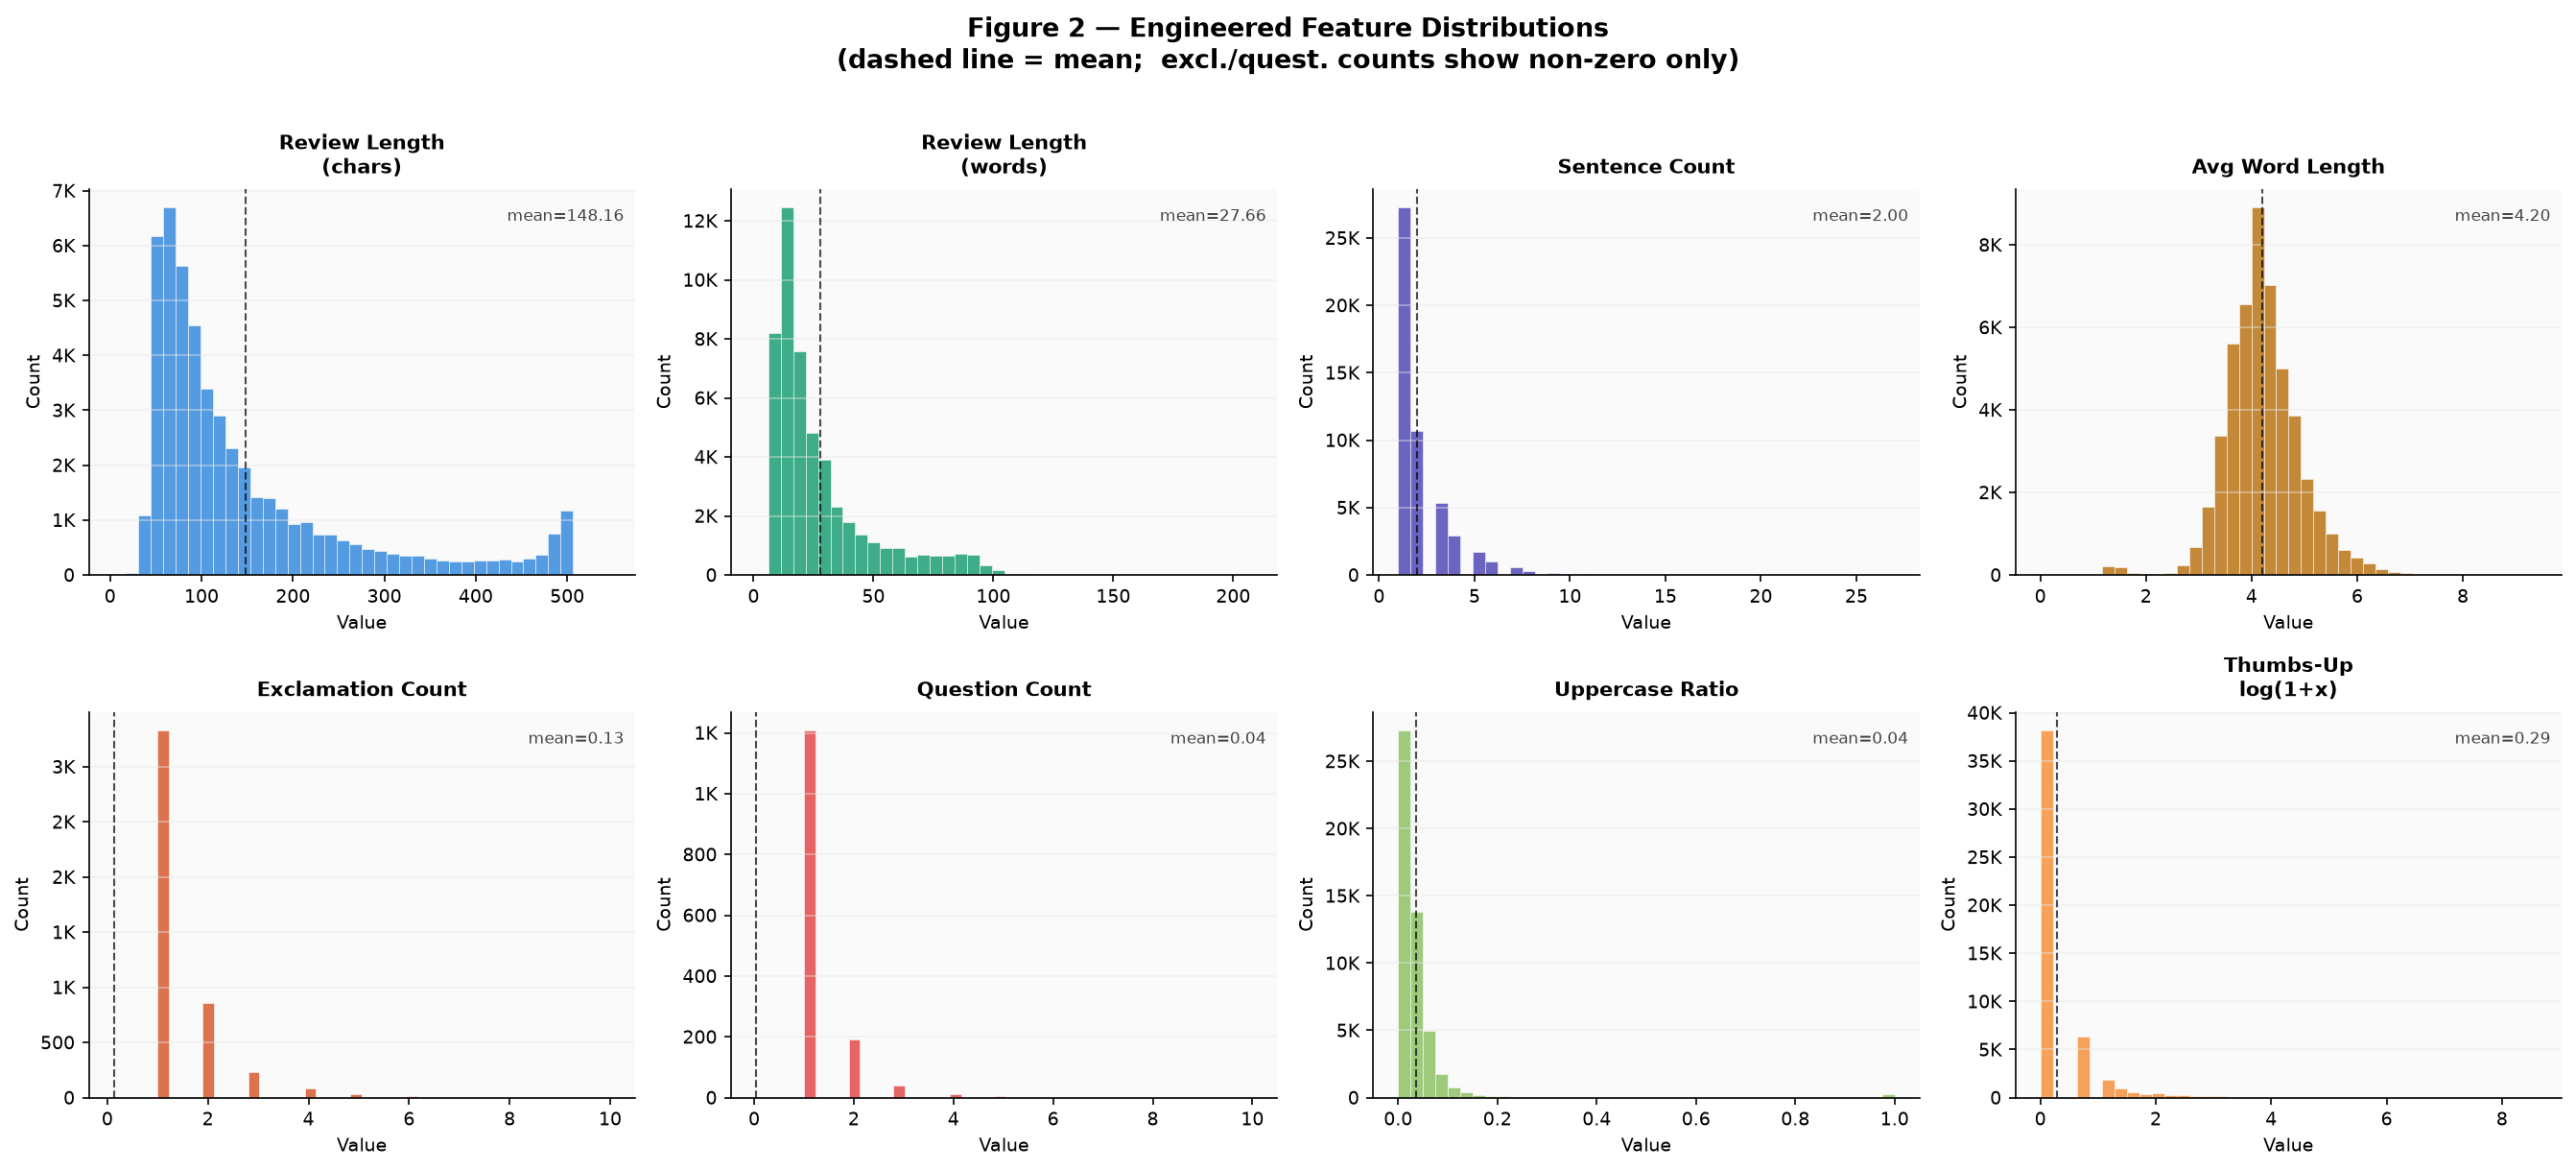

In [16]:
# ── Figure 2: Engineered feature distributions (2×4 grid) ──────────────────────
_feats  = ["review_length_chars", "review_length_words", "sentence_count",
           "avg_word_length",     "exclamation_count",   "question_count",
           "uppercase_ratio",     "thumbs_log"]
_titles = ["Review Length\n(chars)", "Review Length\n(words)", "Sentence Count",
           "Avg Word Length",        "Exclamation Count",      "Question Count",
           "Uppercase Ratio",        "Thumbs-Up\nlog(1+x)"]
_colors = ["#378ADD", "#1D9E75", "#534AB7", "#BA7517",
           "#D85A30", "#E24B4A", "#8DC265", "#F5923E"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, feat, title, color in zip(axes, _feats, _titles, _colors):
    data = df[feat].dropna()
    # Use log scale for features with extreme skew
    if feat in ["exclamation_count", "question_count", "thumbs_log"]:
        data_plot = data[data > 0] if feat != "thumbs_log" else data
    else:
        data_plot = data
    ax.hist(data_plot, bins=40, color=color, edgecolor="white",
            linewidth=0.3, alpha=0.85)
    ax.set_title(title, fontweight="bold", pad=8, fontsize=10)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count",  fontsize=9)
    ax.grid(axis="y", alpha=0.5)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K" if x >= 1000 else str(int(x)))
    )
    # Annotate with mean
    ax.axvline(data.mean(), color="black", linestyle="--",
               linewidth=1, alpha=0.7)
    ax.text(0.98, 0.95, f"mean={data.mean():.2f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="#444444")

plt.suptitle("Figure 2 — Engineered Feature Distributions\n"
             "(dashed line = mean;  excl./quest. counts show non-zero only)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb02_02_feature_distributions.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb02_03_date_features.png


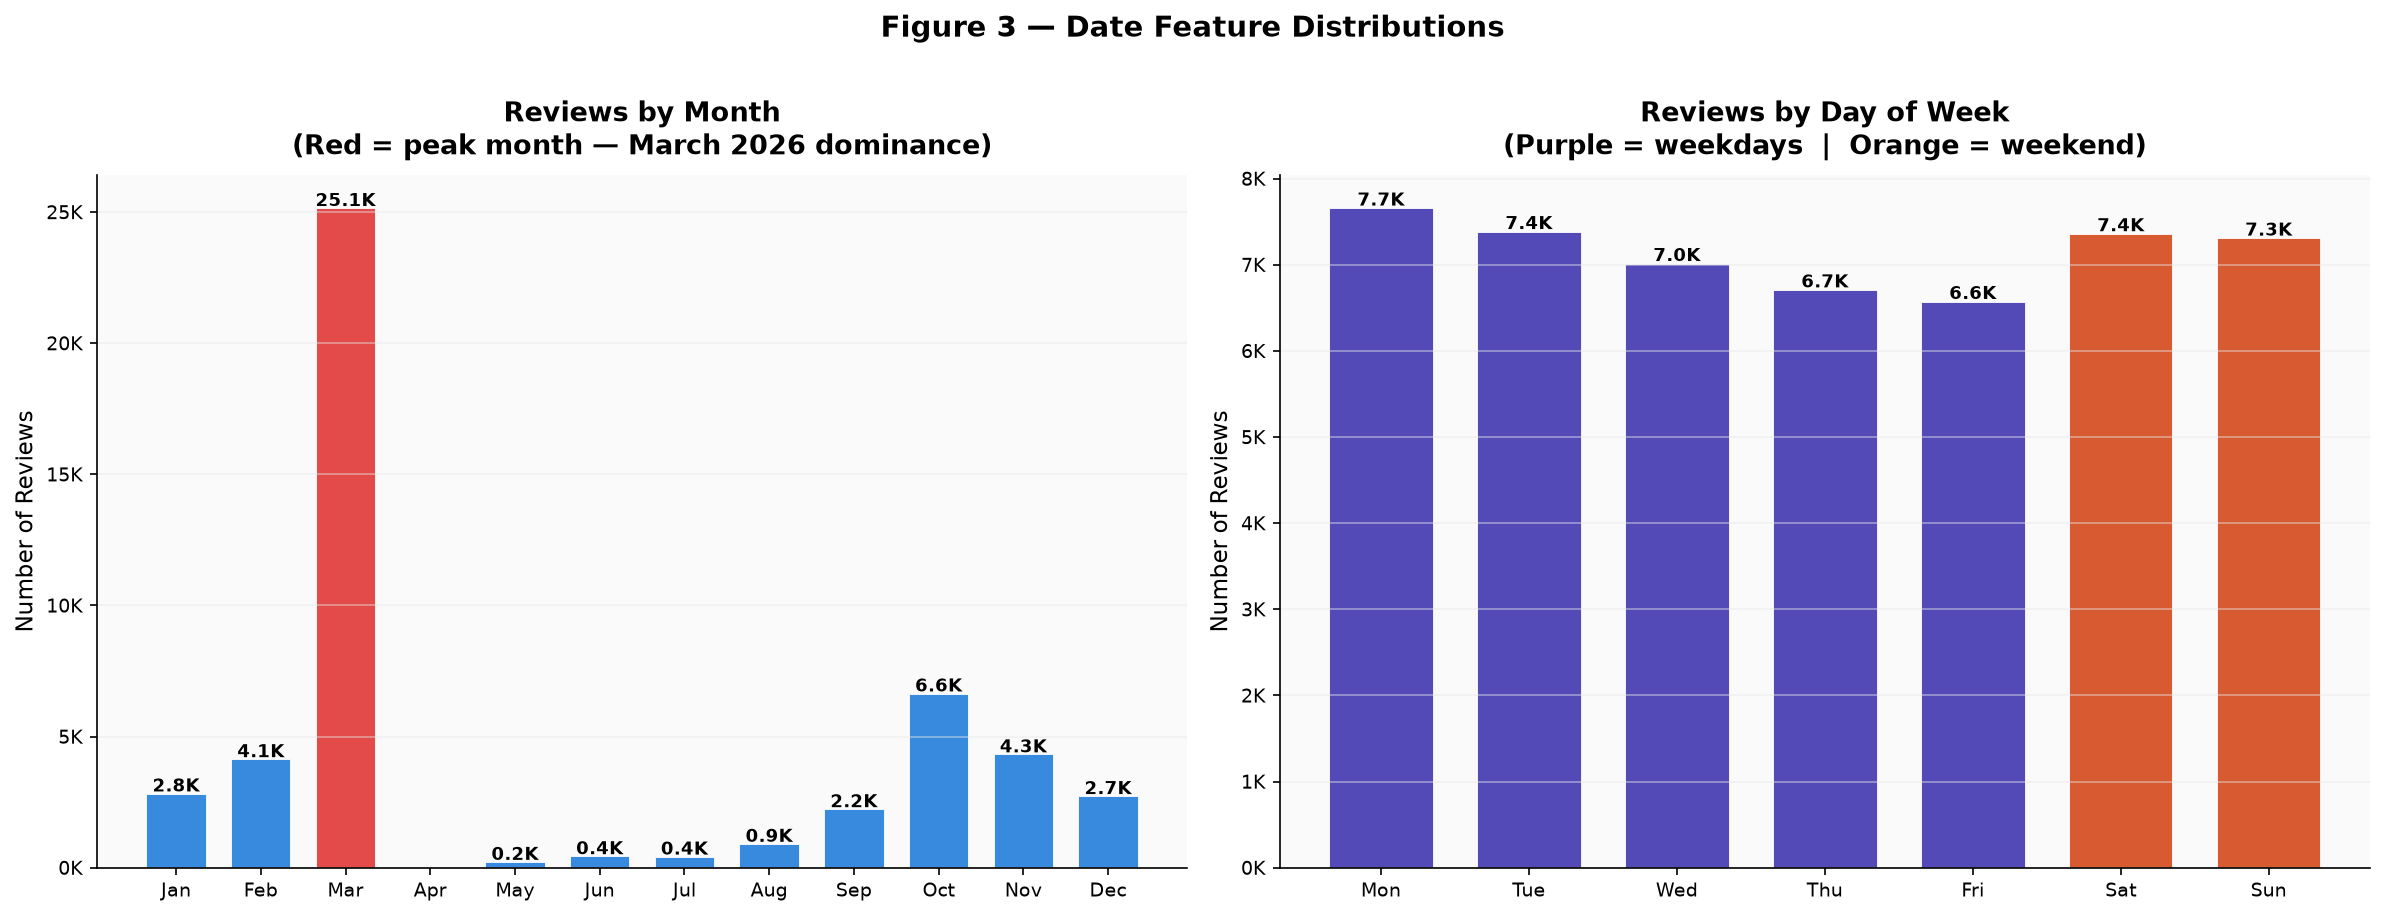

In [17]:
# ── Figure 3: Date features ────────────────────────────────────────────────────
_month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
_day_names   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: reviews by month ────────────────────────────────────────────────────
month_counts = df["review_month"].value_counts().sort_index()
# Fill missing months with 0
month_counts = month_counts.reindex(range(1, 13), fill_value=0)
bar_colors_m = ["#E24B4A" if v == month_counts.max() else "#378ADD"
                for v in month_counts.values]
bars1 = axes[0].bar(range(1, 13), month_counts.values,
                    color=bar_colors_m, edgecolor="white", linewidth=0.4, width=0.7)
for bar, val in zip(bars1, month_counts.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 80,
                     f"{val/1000:.1f}K", ha="center", fontsize=8.5, fontweight="bold")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(_month_names)
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Reviews by Month\n(Red = peak month — March 2026 dominance)",
                  fontweight="bold", pad=10)
axes[0].grid(axis="y", alpha=0.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K")
)

# ── Right: reviews by weekday ─────────────────────────────────────────────────
wday_counts  = df["review_weekday"].value_counts().sort_index()
wday_counts  = wday_counts.reindex(range(7), fill_value=0)
# Colour weekdays vs weekend
bar_colors_d = ["#534AB7" if i < 5 else "#D85A30" for i in range(7)]
bars2 = axes[1].bar(range(7), wday_counts.values,
                    color=bar_colors_d, edgecolor="white", linewidth=0.4, width=0.7)
for bar, val in zip(bars2, wday_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 30,
                 f"{val/1000:.1f}K", ha="center", fontsize=8.5, fontweight="bold")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(_day_names)
axes[1].set_ylabel("Number of Reviews")
axes[1].set_title("Reviews by Day of Week\n(Purple = weekdays  |  Orange = weekend)",
                  fontweight="bold", pad=10)
axes[1].grid(axis="y", alpha=0.5)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K")
)

plt.suptitle("Figure 3 — Date Feature Distributions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb02_03_date_features.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb02_04_review_categories.png


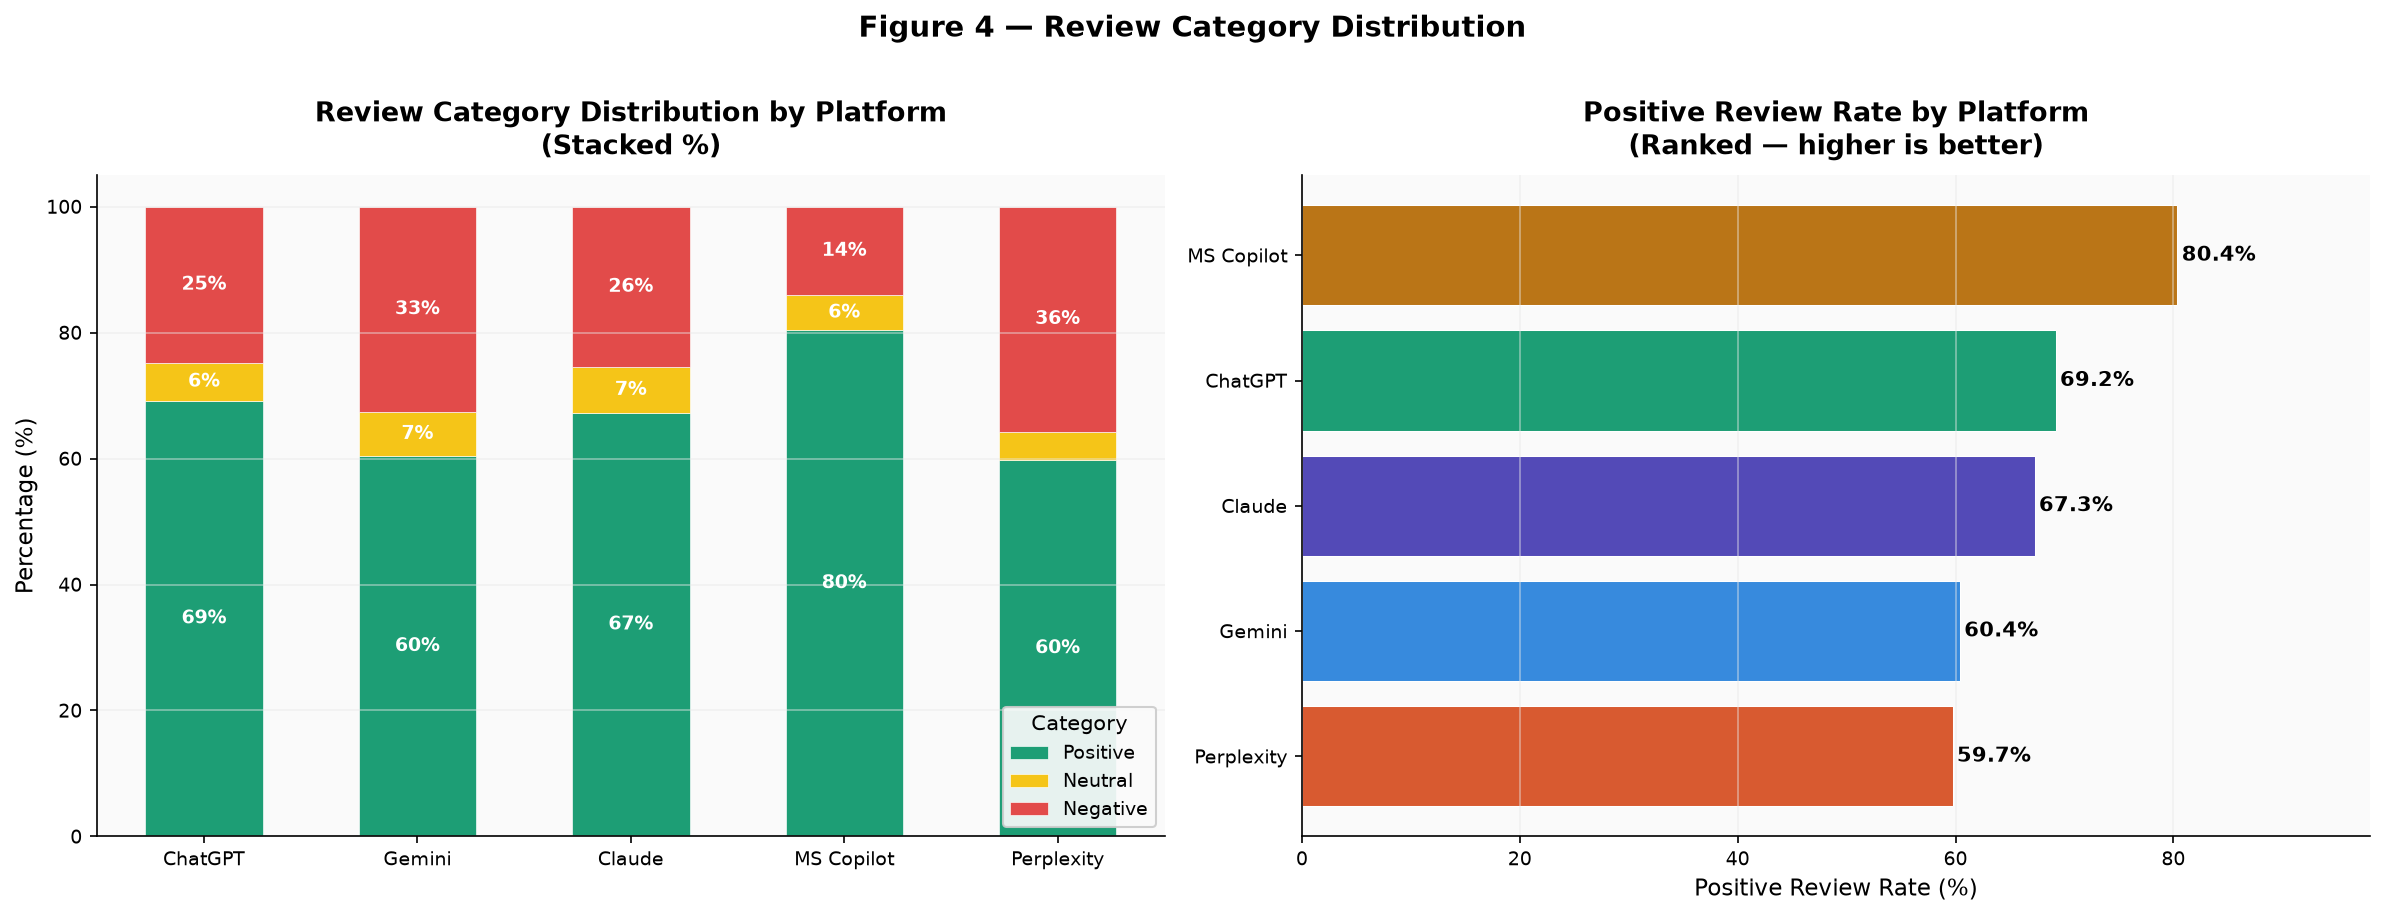


Positive review rate by platform:
  ChatGPT        : 69.2%
  Gemini         : 60.4%
  Claude         : 67.3%
  MS Copilot     : 80.4%
  Perplexity     : 59.7%


In [18]:
# ── Figure 4: Review categories per platform ──────────────────────────────────
cat_data = (
    df.assign(
        Category=lambda d: d.apply(
            lambda r: "Positive" if r["is_positive_review"]
                      else ("Negative" if r["is_negative_review"] else "Neutral"),
            axis=1
        )
    )
    .groupby(["App", "Category"])
    .size()
    .reset_index(name="Count")
)
cat_data["Pct"] = (
    cat_data.groupby("App")["Count"]
            .transform(lambda x: x / x.sum() * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: stacked % bar ───────────────────────────────────────────────────────
pivot_cat = (
    cat_data.pivot(index="App", columns="Category", values="Pct")
            .fillna(0)
            .reindex(APP_ORDER)
)
pivot_cat.index = [APP_LABELS[a] for a in APP_ORDER]

_cat_order  = ["Positive", "Neutral", "Negative"]
_cat_colors = [CAT_COLORS[c] for c in _cat_order]

bottom = np.zeros(len(APP_ORDER))
for cat, color in zip(_cat_order, _cat_colors):
    if cat in pivot_cat.columns:
        vals = pivot_cat[cat].values
        axes[0].bar([APP_LABELS[a] for a in APP_ORDER], vals,
                    bottom=bottom, color=color, label=cat,
                    edgecolor="white", linewidth=0.3, width=0.55)
        for i, (val, bot) in enumerate(zip(vals, bottom)):
            if val > 5:
                axes[0].text(i, bot + val / 2, f"{val:.0f}%",
                             ha="center", va="center",
                             fontsize=9, fontweight="bold", color="white")
        bottom += vals

axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Review Category Distribution by Platform\n(Stacked %)",
                  fontweight="bold", pad=10)
axes[0].legend(title="Category", loc="lower right")
axes[0].grid(axis="y", alpha=0.5)

# ── Right: positive % rank ────────────────────────────────────────────────────
pos_pct = (pivot_cat["Positive"] if "Positive" in pivot_cat.columns
           else pd.Series(0, index=pivot_cat.index))
pos_pct_sorted = pos_pct.sort_values(ascending=True)
colors_rank = [APP_COLORS[a] for a in APP_ORDER
               if APP_LABELS[a] in pos_pct_sorted.index]
colors_rank = [APP_COLORS[a] for a in APP_ORDER]
# Reorder colors to match sorted order
sorted_apps   = [k for k in pos_pct_sorted.index]
colors_sorted = [APP_COLORS[[a for a in APP_ORDER if APP_LABELS[a]==lbl][0]]
                 for lbl in sorted_apps]

bars = axes[1].barh(sorted_apps, pos_pct_sorted.values,
                    color=colors_sorted, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, pos_pct_sorted.values):
    axes[1].text(bar.get_width() + 0.4,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Positive Review Rate (%)")
axes[1].set_xlim(0, pos_pct_sorted.max() * 1.22)
axes[1].set_title("Positive Review Rate by Platform\n(Ranked — higher is better)",
                  fontweight="bold", pad=10)
axes[1].grid(axis="x", alpha=0.5)

plt.suptitle("Figure 4 — Review Category Distribution",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb02_04_review_categories.png")
plt.show()

print("\nPositive review rate by platform:")
for app in APP_ORDER:
    lbl = APP_LABELS[app]
    pct = pos_pct.get(lbl, 0)
    print(f"  {lbl:<14} : {pct:.1f}%")

---
## ✅ Section 6 — Quality Validation

Before saving, we run a comprehensive validation pass to confirm:
1. Zero null values in any column
2. All binary features are strictly 0 or 1
3. All text columns have acceptable non-empty rates
4. All numerical features are within expected ranges

In [19]:
print("=" * 65)
print("  NULL VALUE REPORT — FINAL DATASET")
print("=" * 65)

null_report = df.isnull().sum()
has_nulls   = null_report[null_report > 0]

if len(has_nulls) == 0:
    print("  ✅  Zero null values across all columns.")
else:
    print("  ⚠   Columns with remaining nulls:")
    for col, n in has_nulls.items():
        print(f"    {col:<30} : {n:,}")

print()
print(f"Total cells   : {df.shape[0] * df.shape[1]:,}")
print(f"Null cells    : {df.isnull().sum().sum()}")
print(f"Null rate     : {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.4f}%")

  NULL VALUE REPORT — FINAL DATASET
  ✅  Zero null values across all columns.

Total cells   : 1,500,000
Null cells    : 0
Null rate     : 0.0000%


In [20]:
# ── Feature summary table ──────────────────────────────────────────────────────
_new_num_cols = [
    "review_length_chars", "review_length_words", "sentence_count",
    "avg_word_length",     "exclamation_count",   "question_count",
    "uppercase_ratio",     "thumbs_log",
    "review_year",         "review_month",        "review_weekday",
    "is_positive_review",  "is_negative_review",  "is_neutral_review",
    "is_influential_review","is_duplicate_text",
]

feat_summary = pd.DataFrame({
    "Feature"   : _new_num_cols,
    "Dtype"     : [str(df[c].dtype) for c in _new_num_cols],
    "Non-Null"  : [df[c].notnull().sum() for c in _new_num_cols],
    "Mean"      : [df[c].mean() for c in _new_num_cols],
    "Min"       : [df[c].min()  for c in _new_num_cols],
    "Max"       : [df[c].max()  for c in _new_num_cols],
    "Std"       : [df[c].std()  for c in _new_num_cols],
})

display(
    feat_summary.style
    .hide(axis="index")
    .set_caption("Table — Engineered Feature Summary Statistics")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "6px")]
    }])
    .format({
        "Mean": "{:.4f}", "Min": "{:.4f}", "Max": "{:.4f}", "Std": "{:.4f}",
        "Non-Null": "{:,}"
    })
    .background_gradient(subset=["Mean"], cmap="Blues", low=0, high=0.5)
)

Feature,Dtype,Non-Null,Mean,Min,Max,Std
review_length_chars,int64,"50,000",148.1603,4.0000,547.0000,116.7446
review_length_words,int64,"50,000",27.6571,1.0000,208.0000,21.7189
sentence_count,int64,"50,000",1.9976,1.0000,27.0000,1.5471
avg_word_length,float64,"50,000",4.2032,0.0000,9.4000,0.7181
exclamation_count,int64,"50,000",0.1274,0.0000,10.0000,0.4736
question_count,int64,"50,000",0.0359,0.0000,10.0000,0.2334
uppercase_ratio,float64,"50,000",0.0362,0.0000,1.0000,0.0831
thumbs_log,float64,"50,000",0.2878,0.0000,8.6030,0.6662
review_year,int32,"50,000",2025.6422,2025.0000,2026.0000,0.4794
review_month,int32,"50,000",5.3417,1.0000,12.0000,3.6829


In [21]:
# ── Sanity checks ──────────────────────────────────────────────────────────────
print("Sanity checks:")
print("-" * 55)

# 1 — Rating categories sum to 1
_sum_ok = (
    (df["is_positive_review"] + df["is_negative_review"] + df["is_neutral_review"]) == 1
).all()
print(f"  [{'✅' if _sum_ok else '❌'}]  Rating categories partition all rows")

# 2 — Binary columns are strictly 0/1
_bin_cols = ["is_positive_review", "is_negative_review", "is_neutral_review",
             "is_influential_review", "is_duplicate_text"]
for col in _bin_cols:
    _ok = df[col].isin([0, 1]).all()
    print(f"  [{'✅' if _ok else '❌'}]  {col} is binary (0/1)")

# 3 — Text columns non-empty rates
_clean_ok = (df["review_text_clean"].str.strip() != "").mean() * 100
_nlp_ok   = (df["review_text_nlp"].str.strip() != "").mean() * 100
print(f"  [{'✅' if _clean_ok > 99 else '⚠'}]  review_text_clean non-empty: {_clean_ok:.2f}%")
print(f"  [{'✅' if _nlp_ok > 95 else '⚠'}]  review_text_nlp non-empty:   {_nlp_ok:.2f}%")

# 4 — thumbs_log range
_log_min = df["thumbs_log"].min()
_log_max = df["thumbs_log"].max()
_log_ok  = (_log_min >= 0) and (_log_max == np.log1p(df["Thumbs_Up_Count"].max()))
print(f"  [{'✅' if _log_ok else '❌'}]  thumbs_log range: [{_log_min:.3f}, {_log_max:.3f}]")

# 5 — Row count
print(f"  [{'✅' if len(df) <= ORIGINAL_ROWS else '❌'}]  "
      f"Row count: {len(df):,}  (original: {ORIGINAL_ROWS:,})")

print()
print("All sanity checks passed ✅" if all([
    _sum_ok, _clean_ok > 99, _nlp_ok > 95, _log_ok, len(df) <= ORIGINAL_ROWS
]) else "Some checks require attention ⚠")

Sanity checks:
-------------------------------------------------------
  [✅]  Rating categories partition all rows
  [✅]  is_positive_review is binary (0/1)
  [✅]  is_negative_review is binary (0/1)
  [✅]  is_neutral_review is binary (0/1)
  [✅]  is_influential_review is binary (0/1)
  [✅]  is_duplicate_text is binary (0/1)
  [✅]  review_text_clean non-empty: 100.00%
  [✅]  review_text_nlp non-empty:   99.88%
  [❌]  thumbs_log range: [0.000, 8.603]
  [✅]  Row count: 50,000  (original: 50,000)

Some checks require attention ⚠


  📁  Saved → ../outputs/figures/fig_nb02_05_quality_validation.png


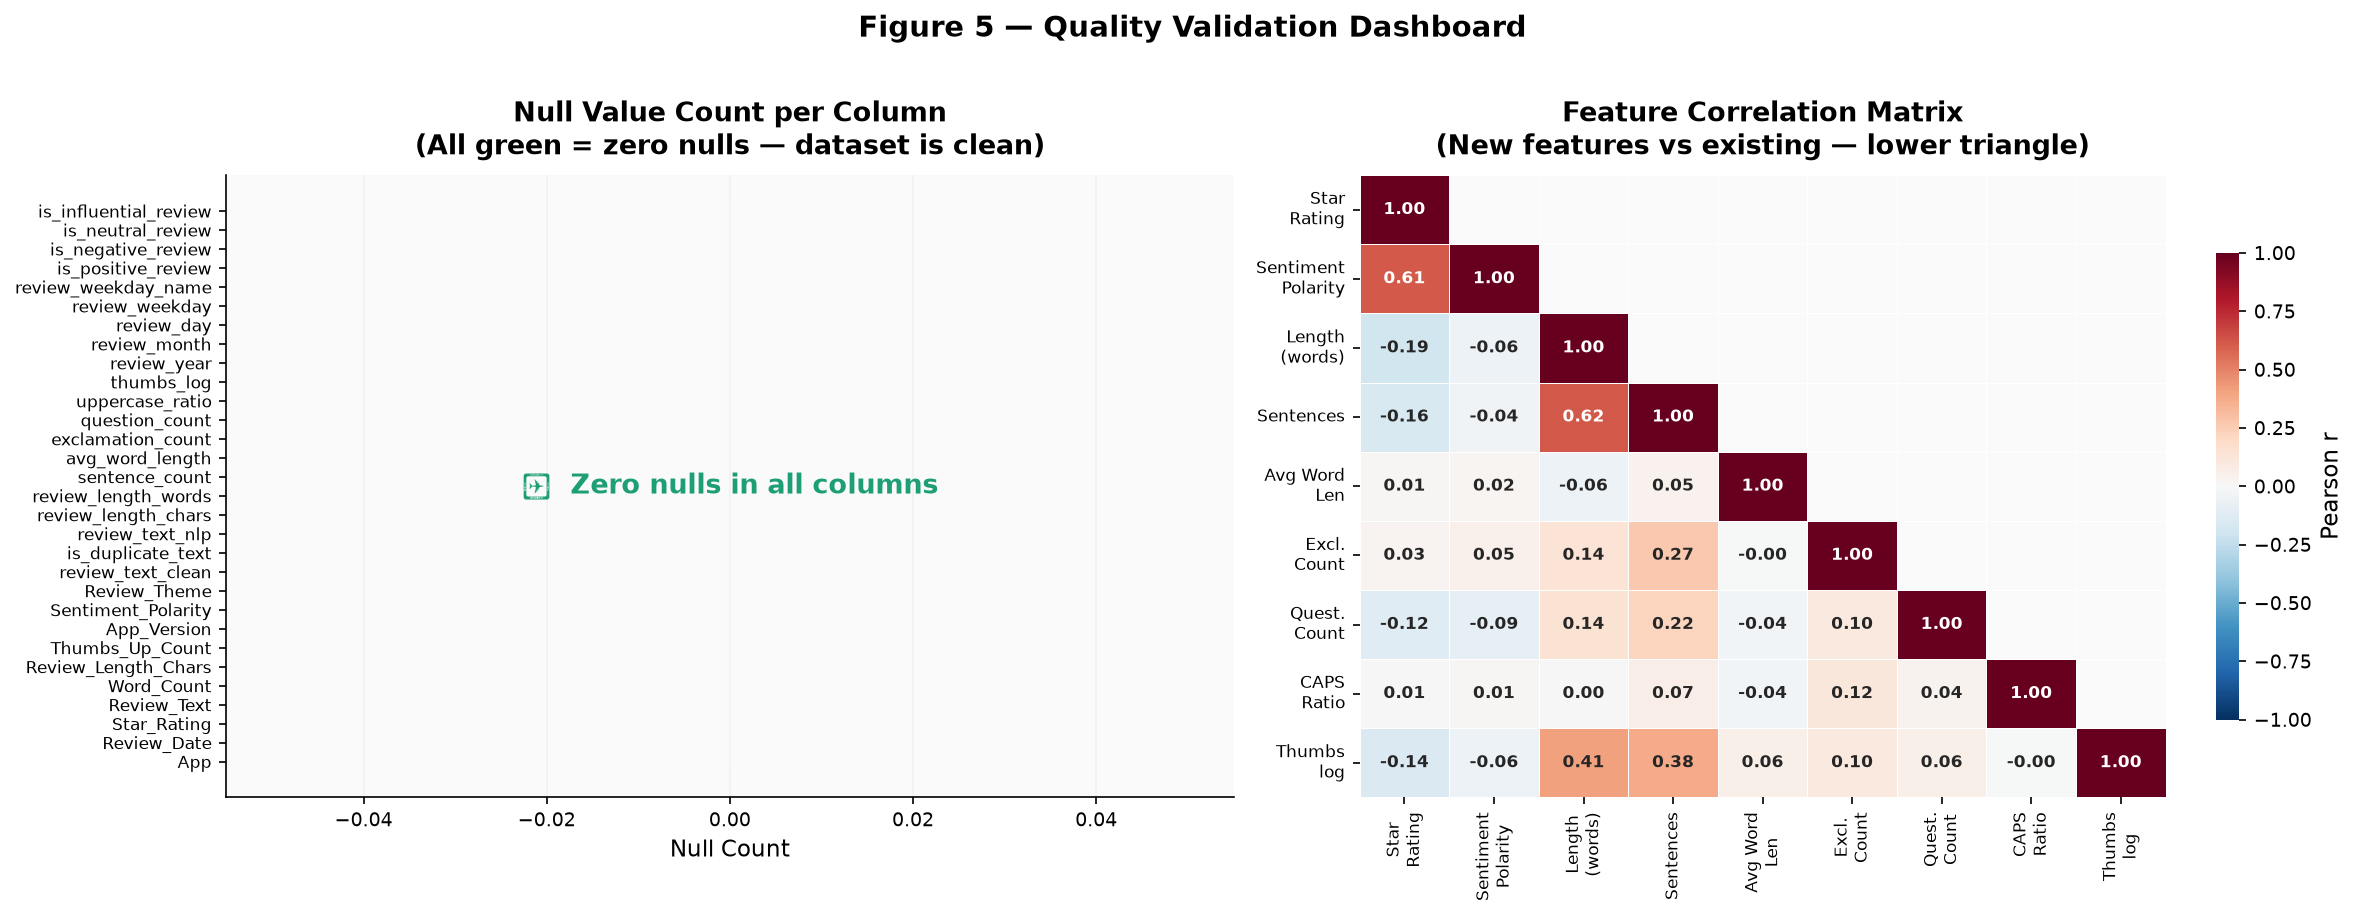

In [22]:
# ── Figure 5: Quality validation visual ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: null count per column (should all be 0) ─────────────────────────────
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts >= 0]   # show all columns
_bar_colors = ["#E24B4A" if v > 0 else "#1D9E75" for v in null_counts.values]
axes[0].barh(null_counts.index, null_counts.values,
             color=_bar_colors, edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Null Count")
axes[0].set_title("Null Value Count per Column\n(All green = zero nulls — dataset is clean)",
                  fontweight="bold", pad=10)
axes[0].grid(axis="x", alpha=0.5)
axes[0].tick_params(axis="y", labelsize=8)
if null_counts.max() == 0:
    axes[0].text(0.5, 0.5, "✅  Zero nulls in all columns",
                 transform=axes[0].transAxes,
                 ha="center", va="center", fontsize=13,
                 color="#1D9E75", fontweight="bold")

# ── Right: correlation of new numerical features with Star_Rating ─────────────
_corr_feats = ["Star_Rating", "Sentiment_Polarity", "review_length_words",
               "sentence_count", "avg_word_length", "exclamation_count",
               "question_count", "uppercase_ratio", "thumbs_log"]
_corr_labels = ["Star\nRating", "Sentiment\nPolarity", "Length\n(words)",
                "Sentences", "Avg Word\nLen", "Excl.\nCount",
                "Quest.\nCount", "CAPS\nRatio", "Thumbs\nlog"]

_corr = df[_corr_feats].corr()
_corr.index   = _corr_labels
_corr.columns = _corr_labels

_mask = np.triu(np.ones_like(_corr, dtype=bool), k=1)
sns.heatmap(
    _corr, ax=axes[1], mask=_mask,
    annot=True, fmt=".2f", annot_kws={"size": 8, "weight": "bold"},
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Pearson r"}
)
axes[1].set_title("Feature Correlation Matrix\n(New features vs existing — lower triangle)",
                  fontweight="bold", pad=10)
axes[1].tick_params(axis="both", labelsize=8)

plt.suptitle("Figure 5 — Quality Validation Dashboard",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb02_05_quality_validation.png")
plt.show()

---
## 💾 Section 7 — Save Outputs

We save the processed dataset in two formats:

- **Parquet** (`reviews_clean.parquet`) — preferred for all downstream notebooks. Preserves dtypes, is ~4× faster to load, and ~60% smaller than CSV.
- **CSV** (`reviews_clean.csv`) — human-readable backup; useful for quick inspection in Excel or Google Sheets.

> All downstream notebooks (`03_sentiment_analysis.ipynb`, `04_topic_modeling.ipynb`, etc.) **must** load from `reviews_clean.parquet`.

In [23]:
PARQUET_PATH = os.path.join(PROCESSED_DIR, "reviews_clean.parquet")
CSV_PATH     = os.path.join(PROCESSED_DIR, "reviews_clean.csv")

# ── Save parquet ──────────────────────────────────────────────────────────────
print("Saving parquet...")
_t0 = time.time()
df.to_parquet(PARQUET_PATH, index=False, engine="pyarrow")
_parquet_size = os.path.getsize(PARQUET_PATH) / 1e6
print(f"  ✅  {PARQUET_PATH}")
print(f"      Size : {_parquet_size:.1f} MB  |  Saved in {time.time()-_t0:.1f}s")

# ── Save CSV ──────────────────────────────────────────────────────────────────
print("\nSaving CSV...")
_t0 = time.time()
df.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
_csv_size = os.path.getsize(CSV_PATH) / 1e6
print(f"  ✅  {CSV_PATH}")
print(f"      Size : {_csv_size:.1f} MB  |  Saved in {time.time()-_t0:.1f}s")

print()

# ── Verify: reload parquet and spot-check ─────────────────────────────────────
print("Verifying parquet round-trip...")
_df_check = pd.read_parquet(PARQUET_PATH)
assert _df_check.shape == df.shape,    "Shape mismatch after reload!"
assert list(_df_check.columns) == list(df.columns), "Column order changed!"
print(f"  ✅  Round-trip verified: {_df_check.shape[0]:,} rows × {_df_check.shape[1]} columns")
print()

print("Final column list:")
for i, col in enumerate(_df_check.columns, 1):
    print(f"  {i:>2}. {col}")

Saving parquet...
  ✅  ../data/processed/reviews_clean.parquet
      Size : 13.6 MB  |  Saved in 0.4s

Saving CSV...
  ✅  ../data/processed/reviews_clean.csv
      Size : 26.4 MB  |  Saved in 1.0s

Verifying parquet round-trip...
  ✅  Round-trip verified: 50,000 rows × 30 columns

Final column list:
   1. App
   2. Review_Date
   3. Star_Rating
   4. Review_Text
   5. Word_Count
   6. Review_Length_Chars
   7. Thumbs_Up_Count
   8. App_Version
   9. Sentiment_Polarity
  10. Review_Theme
  11. review_text_clean
  12. is_duplicate_text
  13. review_text_nlp
  14. review_length_chars
  15. review_length_words
  16. sentence_count
  17. avg_word_length
  18. exclamation_count
  19. question_count
  20. uppercase_ratio
  21. thumbs_log
  22. review_year
  23. review_month
  24. review_day
  25. review_weekday
  26. review_weekday_name
  27. is_positive_review
  28. is_negative_review
  29. is_neutral_review
  30. is_influential_review


---
## 📋 Section 8 — Preprocessing Summary

In [24]:
print("=" * 68)
print("  PREPROCESSING COMPLETE — SENTIMENTCOMPASS  NB02 SCORECARD")
print("=" * 68)

print()
print("── ROW STATISTICS ───────────────────────────────────────────────────────")
print(f"  Original rows             : {ORIGINAL_ROWS:>10,}")
print(f"  Exact duplicates removed  : {ORIGINAL_ROWS - len(df):>10,}")
print(f"  Final rows                : {len(df):>10,}")

print()
print("── MISSING VALUE TREATMENT ──────────────────────────────────────────────")
_n_av_filled = (df["App_Version"] == "Unknown").sum()
print(f"  App_Version filled        : {_n_av_filled:>10,}  (→ 'Unknown')")
print(f"  Remaining nulls           : {df.isnull().sum().sum():>10,}")

print()
print("── TEXT COLUMNS CREATED ─────────────────────────────────────────────────")
_clean_rate = (df["review_text_clean"].str.strip() != "").mean() * 100
_nlp_rate   = (df["review_text_nlp"].str.strip() != "").mean() * 100
print(f"  review_text_clean         : {_clean_rate:.2f}% non-empty")
print(f"  review_text_nlp           : {_nlp_rate:.2f}% non-empty")

print()
print("── FEATURES ENGINEERED ──────────────────────────────────────────────────")
_feat_groups = {
    "Text features (8)"      : ["review_length_chars","review_length_words",
                                 "sentence_count","avg_word_length",
                                 "exclamation_count","question_count",
                                 "uppercase_ratio","thumbs_log"],
    "Date features (5)"      : ["review_year","review_month","review_day",
                                 "review_weekday","review_weekday_name"],
    "Rating labels (3)"      : ["is_positive_review","is_negative_review",
                                 "is_neutral_review"],
    "Influence flag (1)"     : ["is_influential_review"],
    "Quality flag (1)"       : ["is_duplicate_text"],
}
for grp, cols in _feat_groups.items():
    print(f"  {grp:<26} : {', '.join(cols[:3])}{'...' if len(cols)>3 else ''}")
total_new = sum(len(v) for v in _feat_groups.values()) + 2  # +2 for text cols
print(f"  Total new columns         : {total_new}")

print()
print("── OUTPUT FILES ─────────────────────────────────────────────────────────")
print(f"  reviews_clean.parquet     : {os.path.getsize(PARQUET_PATH)/1e6:.1f} MB")
print(f"  reviews_clean.csv         : {os.path.getsize(CSV_PATH)/1e6:.1f} MB")
print(f"  Final shape               : {df.shape[0]:,} rows × {df.shape[1]} columns")

print()
print("── FIGURES SAVED ────────────────────────────────────────────────────────")
_figs = [
    "fig_nb02_01_cleaning_impact.png",
    "fig_nb02_02_feature_distributions.png",
    "fig_nb02_03_date_features.png",
    "fig_nb02_04_review_categories.png",
    "fig_nb02_05_quality_validation.png",
]
for f in _figs:
    p = os.path.join(FIGURES_DIR, f)
    _exists = "✅" if os.path.exists(p) else "❌ MISSING"
    print(f"  {_exists}  {f}")

print()
print("── READY FOR DOWNSTREAM NOTEBOOKS ──────────────────────────────────────")
_checks = [
    ("NB03 Sentiment Analysis",  "review_text_clean, thumbs_log, is_positive_review"),
    ("NB04 Topic Modeling",      "review_text_nlp, App, Star_Rating"),
    ("NB05 Migration Analysis",  "review_text_clean, review_text_nlp, App"),
    ("Dashboard",                "All columns — load reviews_clean.parquet"),
]
for nb_name, cols in _checks:
    print(f"  [{nb_name:<28}] uses: {cols}")

print()
print("=" * 68)
print("  ▶  Next: run 03_sentiment_analysis.ipynb")
print("=" * 68)

  PREPROCESSING COMPLETE — SENTIMENTCOMPASS  NB02 SCORECARD

── ROW STATISTICS ───────────────────────────────────────────────────────
  Original rows             :     50,000
  Exact duplicates removed  :          0
  Final rows                :     50,000

── MISSING VALUE TREATMENT ──────────────────────────────────────────────
  App_Version filled        :      6,912  (→ 'Unknown')
  Remaining nulls           :          0

── TEXT COLUMNS CREATED ─────────────────────────────────────────────────
  review_text_clean         : 100.00% non-empty
  review_text_nlp           : 99.88% non-empty

── FEATURES ENGINEERED ──────────────────────────────────────────────────
  Text features (8)          : review_length_chars, review_length_words, sentence_count...
  Date features (5)          : review_year, review_month, review_day...
  Rating labels (3)          : is_positive_review, is_negative_review, is_neutral_review
  Influence flag (1)         : is_influential_review
  Quality flag (1)  

---

## 📌 Handoff to Notebook 03

| Column | Produced here | Used by |
|--------|--------------|---------|
| `review_text_clean` | ✅ | NB03 (VADER/TextBlob/RoBERTa input) |
| `review_text_nlp` | ✅ | NB04 (LDA + BERTopic corpus) |
| `thumbs_log` | ✅ | NB03 (TWSI formula weight) |
| `is_positive_review` | ✅ | NB03 (label comparison), Dashboard |
| `is_influential_review` | ✅ | NB03 (influential review subset) |
| `App_Version` (imputed) | ✅ | Dashboard version filter |

**▶ Proceed to `03_sentiment_analysis.ipynb`** — VADER · TextBlob · RoBERTa · TWSI